In [4]:
# 2. CHARGEMENT DES DONNÉES ET PRÉPARATION

# Chargement des datasets d'entraînement et de test
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Séparation des features (X) et de la variable cible (y)
# On enlève 'Id' car elle n'a aucune utilité, et 'SalePrice' car c'est la variable qu'on veut prédire.
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)

# Transformation Logarithmique de la Target
y_train = np.log1p(train_df['SalePrice'])

# Préparation du dataset de test (on garde juste l'Id de côté pour la soumission finale)
X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [5]:
# 3. IDENTIFICATION DES VARIABLES ET DIAGNOSTIC DES DONNÉES

# On identifie automatiquement quelles colonnes sont numériques et lesquelles sont des catégories
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

print("="*70)
print("📊 DIAGNOSTIC INITIAL DES DONNÉES")
print("="*70)

# Données manquantes
print(f"\n1️⃣  DONNÉES MANQUANTES :")
missing_counts = X_train.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
if len(missing_counts) > 0:
    print(f"   {len(missing_counts)} colonnes avec valeurs manquantes :")
    for col, count in missing_counts.items():
        pct = 100 * count / len(X_train)
        print(f"      • {col:20s} : {count:4d} valeurs manquantes ({pct:5.1f}%)")
else:
    print("   ✅ Aucune valeur manquante détectée")

print(f"\n2️⃣  TYPES DE VARIABLES :")
print(f"   • Variables numériques : {len(numeric_features)}")
print(f"   • Variables catégorielles : {len(categorical_features)}")

# ============================================================================
# 🚨 DÉTECTION DES OUTLIERS (Méthode IQR)
# ============================================================================

print(f"\n3️⃣  DÉTECTION DES OUTLIERS (Méthode IQR) :")

def detect_outliers_iqr(data, column):
    """Détecte les outliers en utilisant la méthode Interquartile Range (IQR)"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound)

# Compter les outliers par variable numérique
outlier_summary = {}
for col in numeric_features:
    outlier_mask = detect_outliers_iqr(X_train, col)
    n_outliers = outlier_mask.sum()
    pct_outliers = 100 * n_outliers / len(X_train)
    
    if n_outliers > 0:
        outlier_summary[col] = (n_outliers, pct_outliers)
        print(f"   • {col:20s} : {n_outliers:4d} outliers ({pct_outliers:5.1f}%)")

if len(outlier_summary) == 0:
    print("   ✅ Peu ou pas d'outliers problématiques détectés")
else:
    total_outliers = sum(x[0] for x in outlier_summary.values())
    print(f"\n   ⚠️  Total : {total_outliers} outliers trouvés")
    print(f"   💡 Note : RobustScaler va les gérer automatiquement dans le pipeline")
    print(f"   💡 Note : Lasso va aussi réduire leur impact via la régularisation")

📊 DIAGNOSTIC INITIAL DES DONNÉES

1️⃣  DONNÉES MANQUANTES :
   19 colonnes avec valeurs manquantes :
      • PoolQC               : 1453 valeurs manquantes ( 99.5%)
      • MiscFeature          : 1406 valeurs manquantes ( 96.3%)
      • Alley                : 1369 valeurs manquantes ( 93.8%)
      • Fence                : 1179 valeurs manquantes ( 80.8%)
      • MasVnrType           :  872 valeurs manquantes ( 59.7%)
      • FireplaceQu          :  690 valeurs manquantes ( 47.3%)
      • LotFrontage          :  259 valeurs manquantes ( 17.7%)
      • GarageType           :   81 valeurs manquantes (  5.5%)
      • GarageYrBlt          :   81 valeurs manquantes (  5.5%)
      • GarageFinish         :   81 valeurs manquantes (  5.5%)
      • GarageQual           :   81 valeurs manquantes (  5.5%)
      • GarageCond           :   81 valeurs manquantes (  5.5%)
      • BsmtExposure         :   38 valeurs manquantes (  2.6%)
      • BsmtFinType2         :   38 valeurs manquantes (  2.6%)
   

C:\Users\Digi\AppData\Local\Temp\ipykernel_4352\3424270922.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object']).columns


In [11]:
# 3.5 CUSTOM TARGET ENCODER (remplace OneHotEncoder)

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Encode les variables catégorielles par la MOYENNE de y (SalePrice) pour chaque catégorie.
    
    ✅ Avantages :
    - Prédictions CONSERVATRICES (= moyenne observée) 🏦
    - Meilleure sélection de variables pour Lasso
    - Préserve l'ordre ordinal (low < medium < high)
    - Pas d'explosion dimensionnelle (3 catégories → 1 colonne, pas 3)
    - Capture la vraie relation entre catégorie et prix
    
    🏦 PARFAIT POUR LES BANQUES : prix minimal garanti en cas de saisie
    """
    
    def __init__(self, smoothing=1.0):
        """
        smoothing: float
            Régularisation pour éviter l'overfitting sur catégories rares.
            - smoothing=0.0 : moyenne pure (risqué si catégories rares)
            - smoothing=1.0 : équilibre (recommandé) ← START HERE
            - smoothing=5.0+ : très conservateur
        """
        self.smoothing = smoothing
        self.target_means = {}
        self.global_mean = None
    
    def fit(self, X, y):
        """Apprendre la moyenne de y pour chaque valeur unique de chaque colonne"""
        
        self.global_mean = y.mean()
        
        for col in X.columns:
            # Calculer la moyenne de y pour chaque catégorie
            category_means = X[col].groupby(X[col]).apply(lambda indices: y[indices].mean())
            
            # Compter combien de fois chaque catégorie apparaît
            category_counts = X[col].value_counts()
            
            # Appliquer le smoothing (régularisation)
            # = mélanger la moyenne de la catégorie avec la moyenne globale
            smoothed_means = (
                category_means * category_counts / (category_counts + self.smoothing) +
                self.global_mean * self.smoothing / (category_counts + self.smoothing)
            )
            
            self.target_means[col] = smoothed_means
        
        return self
    
    def transform(self, X):
        """Remplacer chaque catégorie par la moyenne de y apprise"""
        X_encoded = X.copy()
        
        for col in X.columns:
            # Mapper chaque valeur par sa moyenne
            X_encoded[col] = X[col].map(self.target_means[col])
            
            # Si une catégorie existe en test mais pas en train → utiliser moyenne globale
            X_encoded[col].fillna(self.global_mean, inplace=True)
        
        return X_encoded

In [15]:
# 3.5 CUSTOM TARGET ENCODER (remplace OneHotEncoder)

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Encode les variables catégorielles par la MOYENNE de y (SalePrice) pour chaque catégorie.
    
    ✅ Avantages :
    - Prédictions CONSERVATRICES (= moyenne observée) 🏦
    - Meilleure sélection de variables pour Lasso
    - Préserve l'ordre ordinal (low < medium < high)
    - Pas d'explosion dimensionnelle (3 catégories → 1 colonne, pas 3)
    - Capture la vraie relation entre catégorie et prix
    
    🏦 PARFAIT POUR LES BANQUES : prix minimal garanti en cas de saisie
    """
    
    def __init__(self, smoothing=1.0):
        """
        smoothing: float
            Régularisation pour éviter l'overfitting sur catégories rares.
            - smoothing=0.0 : moyenne pure (risqué si catégories rares)
            - smoothing=1.0 : équilibre (recommandé) ← START HERE
            - smoothing=5.0+ : très conservateur
        """
        self.smoothing = smoothing
        self.target_means = {}
        self.global_mean = None
        self.n_features_in_ = None
        self.feature_names_in_ = None
    
    def fit(self, X, y):
        """Apprendre la moyenne de y pour chaque valeur unique de chaque colonne"""
        
        # Gérer les deux cas : DataFrame ou array
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=[f"col_{i}" for i in range(X.shape[1])])
        else:
            X_df = X
            self.feature_names_in_ = np.array(X.columns)
        
        self.n_features_in_ = X_df.shape[1]
        self.global_mean = y.mean() if isinstance(y, pd.Series) else y.mean()
        
        for col in X_df.columns:
            # Calculer la moyenne de y pour chaque catégorie
            category_means = X_df[col].groupby(X_df[col]).apply(
                lambda indices: y.iloc[indices.index].mean() if isinstance(y, pd.Series) else y[indices.index].mean()
            )
            
            # Compter combien de fois chaque catégorie apparaît
            category_counts = X_df[col].value_counts()
            
            # Appliquer le smoothing (régularisation)
            smoothed_means = (
                category_means * category_counts / (category_counts + self.smoothing) +
                self.global_mean * self.smoothing / (category_counts + self.smoothing)
            )
            
            self.target_means[col] = smoothed_means
        
        return self
    
    def transform(self, X):
        """Remplacer chaque catégorie par la moyenne de y apprise"""
        
        # Gérer les deux cas : DataFrame ou array
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=[f"col_{i}" for i in range(X.shape[1])])
        else:
            X_df = X.copy()
        
        X_encoded = X_df.copy()
        
        for col in X_df.columns:
            # Mapper chaque valeur par sa moyenne
            X_encoded[col] = X_df[col].map(self.target_means[col])
            
            # Si une catégorie existe en test mais pas en train → utiliser moyenne globale
            X_encoded[col].fillna(self.global_mean, inplace=True)
        
        return X_encoded.values
    
    def get_feature_names_out(self, input_features=None):
        """Retourner les noms de colonnes après transformation"""
        if input_features is None:
            input_features = self.feature_names_in_
        return np.array(input_features)

In [17]:
# 5. CRÉATION ET ENTRAÎNEMENT DU MODÈLE GLOBAL (PIPELINE)

# ATTENTION : Redéfinir la classe TargetEncoder dans cette cellule pour s'assurer qu'elle est à jour

class TargetEncoder(BaseEstimator, TransformerMixin):
    """Encode les variables catégorielles par la MOYENNE de y"""
    
    def __init__(self, smoothing=1.0):
        self.smoothing = smoothing
        self.target_means = {}
        self.global_mean = None
        self.feature_names_in_ = None
    
    def fit(self, X, y):
        """Apprendre la moyenne de y pour chaque catégorie"""
        
        # Gérer X en array ou DataFrame
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=[f"col_{i}" for i in range(X.shape[1])])
        else:
            X_df = X
            self.feature_names_in_ = np.array(X.columns)
        
        self.global_mean = y.mean() if isinstance(y, pd.Series) else y.mean()
        
        for col in X_df.columns:
            category_means = X_df[col].groupby(X_df[col]).apply(
                lambda indices: y.iloc[indices.index].mean() if isinstance(y, pd.Series) else y[indices.index].mean()
            )
            category_counts = X_df[col].value_counts()
            
            smoothed_means = (
                category_means * category_counts / (category_counts + self.smoothing) +
                self.global_mean * self.smoothing / (category_counts + self.smoothing)
            )
            
            self.target_means[col] = smoothed_means
        
        return self
    
    def transform(self, X):
        """Remplacer chaque catégorie par sa moyenne y"""
        
        if isinstance(X, np.ndarray):
            X_df = pd.DataFrame(X, columns=[f"col_{i}" for i in range(X.shape[1])])
        else:
            X_df = X.copy()
        
        X_encoded = X_df.copy()
        
        for col in X_df.columns:
            X_encoded[col] = X_df[col].map(self.target_means[col])
            X_encoded[col].fillna(self.global_mean, inplace=True)
        
        return X_encoded.values
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array(list(self.target_means.keys()))
        return np.array(input_features)


# Recréer la pipeline avec le nouveau TargetEncoder
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=1.0))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# LassoCV va tester différentes valeurs d'alpha
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, random_state=42, max_iter=10000))
])

# ENTRAÎNEMENT DU MODÈLE
print("\n" + "="*70)
print("🚀 ENTRAÎNEMENT DU MODÈLE EN COURS...")
print("="*70)
print("\nÉtapes :")
print("  1. Imputation des valeurs manquantes")
print("  2. Normalisation des variables numériques (RobustScaler)")
print("  3. Encodage des variables catégorielles (Target Encoding)")
print("  4. Entraînement de Lasso avec recherche du meilleur alpha (CV=5)\n")

pipeline_lasso.fit(X_train, y_train)

# On récupère le meilleur paramètre alpha trouvé par le modèle
best_alpha = pipeline_lasso.named_steps['model'].alpha_
print(f"✅ Entraînement terminé !")
print(f"   Meilleur hyperparamètre alpha trouvé : {best_alpha:.5f}")

# Évaluation rapide sur le set d'entraînement
y_pred_train = pipeline_lasso.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Convertir en dollars pour interpréter
y_pred_dollars = np.expm1(y_pred_train)
y_real_dollars = np.expm1(y_train)
mae_dollars = np.mean(np.abs(y_pred_dollars - y_real_dollars))

print(f"\n📊 MÉTRIQUES SUR LE SET D'ENTRAÎNEMENT :")
print(f"   • RMSE (log) : {rmse_train:.4f}")
print(f"   • MAE (log) : {mae_train:.4f}")
print(f"   • R² Score : {r2_train:.4f}")
print(f"   • MAE en dollars : ${mae_dollars:,.0f}")
print(f"\n💡 Interprétation : En moyenne, le modèle se trompe de ±${mae_dollars:,.0f}")


🚀 ENTRAÎNEMENT DU MODÈLE EN COURS...

Étapes :
  1. Imputation des valeurs manquantes
  2. Normalisation des variables numériques (RobustScaler)
  3. Encodage des variables catégorielles (Target Encoding)
  4. Entraînement de Lasso avec recherche du meilleur alpha (CV=5)

✅ Entraînement terminé !
   Meilleur hyperparamètre alpha trouvé : 0.00396

📊 MÉTRIQUES SUR LE SET D'ENTRAÎNEMENT :
   • RMSE (log) : 0.1382
   • MAE (log) : 0.0924
   • R² Score : 0.8802
   • MAE en dollars : $16,781

💡 Interprétation : En moyenne, le modèle se trompe de ±$16,781


C:\Users\Digi\AppData\Local\Temp\ipykernel_4352\1592665187.py:53: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_encoded[col].fillna(self.global_mean, inplace=True)
C:\Users\Digi\AppData\Local\Temp\ipykernel_4352\1592665187.py:53: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignm

In [19]:
# 5.5 VISUALISATION : EXEMPLES D'ENCODAGE (Target Encoding)

print("\n" + "="*70)
print("🎯 EXEMPLES D'ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*70)

# Récupérer le Target Encoder
target_encoder = pipeline_lasso.named_steps['preprocessor'].named_transformers_['cat'].named_steps['target_encoder']

# Afficher 3 exemples de variables catégorielles encodées
print("\n📌 Exemples de variables catégorielles avec leurs encodages :\n")

exemples_display = categorical_features[:min(3, len(categorical_features))]
for col in exemples_display:
    print(f"Variable : '{col}'")
    print(f"  Nombre de catégories : {X_train[col].nunique()}")
    
    # Obtenir les encodages
    encodages = target_encoder.target_means[col].sort_values()
    
    print(f"  Encodages (Prix moyen en log) :")
    for category, encoded_value in encodages.items():
        price_dollars = np.expm1(encoded_value)
        print(f"    • {str(category):20s} → Log: {encoded_value:8.4f} (${price_dollars:>10,.0f})")
    print()

print("💡 COMPARAISON : Target Encoding vs One-Hot Encoding")
print(f"   • One-Hot Encoding : {len(numeric_features)} + ~100+ colonnes = explosion dimensionnelle ❌")
print(f"   • Target Encoding : {len(numeric_features)} + {len(categorical_features)} colonnes = conservateur ✅")
print(f"   • Information préservée : OUI, chaque catégorie encode sa vraie relation avec le prix 🏦")


🎯 EXEMPLES D'ENCODAGE DES VARIABLES CATÉGORIELLES

📌 Exemples de variables catégorielles avec leurs encodages :

Variable : 'MSZoning'
  Nombre de catégories : 5


KeyError: 'MSZoning'

In [20]:
# 6. INTERPRÉTATION : ANALYSE DES COEFFICIENTS (Sélection de variables)

print("\n" + "="*70)
print("🔍 ANALYSE DE LA SÉLECTION DE VARIABLES PAR LASSO")
print("="*70)

# Récupération du modèle Lasso entraîné
lasso_model = pipeline_lasso.named_steps['model']

# Compter combien de variables ont été gardées (coefficient différent de 0) et éliminées (coefficient = 0)
coeffs = lasso_model.coef_
features_gardees = np.sum(coeffs != 0)
features_eliminees = np.sum(coeffs == 0)
total_features = len(coeffs)

print(f"\n✨ Magie du Lasso avec l'hyperparamètre alpha = {best_alpha:.5f}")
print(f"   Total de variables créées après preprocessing : {total_features}")
print(f"   └─ Variables numériques : {len(numeric_features)}")
print(f"   └─ Variables catégorielles (Target Encoded) : {len(categorical_features)}")
print(f"\n📊 Résultat de la sélection :")
print(f"   ✅ Conservées (coeff ≠ 0) : {features_gardees} ({100*features_gardees/total_features:.1f}%)")
print(f"   ❌ Éliminées (coeff = 0)  : {features_eliminees} ({100*features_eliminees/total_features:.1f}%)")
print(f"\n💡 Interprétation : Le Lasso considère que {features_eliminees} variables ne sont pas utiles")
print(f"                  pour prédire le prix de la maison.")
print(f"                  Cette sélection automatique aide à identifier les variables vraiment importantes.")


🔍 ANALYSE DE LA SÉLECTION DE VARIABLES PAR LASSO

✨ Magie du Lasso avec l'hyperparamètre alpha = 0.00396
   Total de variables créées après preprocessing : 79
   └─ Variables numériques : 36
   └─ Variables catégorielles (Target Encoded) : 43

📊 Résultat de la sélection :
   ✅ Conservées (coeff ≠ 0) : 27 (34.2%)
   ❌ Éliminées (coeff = 0)  : 52 (65.8%)

💡 Interprétation : Le Lasso considère que 52 variables ne sont pas utiles
                  pour prédire le prix de la maison.
                  Cette sélection automatique aide à identifier les variables vraiment importantes.


In [21]:
# 7. PRÉDICTIONS SUR LE TEST SET ET SOUMISSION KAGGLE

# Prédire les prix pour le dataset de test
# prédictions en logarithme
preds_log = pipeline_lasso.predict(X_test)

# On applique l'exponentielle (np.expm1) pour annuler le logarithme et retrouver les prix en vrais dollars ($)
preds_dollars = np.expm1(preds_log)

# Création du DataFrame final au format attendu par Kaggle
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars
})

# Sauvegarde au format CSV (sans l'index par défaut de pandas)
fichier_soumission = 'M1_Lasso_Submission.csv'
submission.to_csv(fichier_soumission, index=False)

print(f"Fichier '{fichier_soumission}' généré avec succès ! ")
submission.head()

Fichier 'M1_Lasso_Submission.csv' généré avec succès ! 


C:\Users\Digi\AppData\Local\Temp\ipykernel_4352\1592665187.py:53: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X_encoded[col].fillna(self.global_mean, inplace=True)


,Id,SalePrice
0,1461,123509.327300
1,1462,140902.535356
2,1463,169618.260952
3,1464,193914.532871
4,1465,203704.434187


C:\Users\Digi\AppData\Local\Temp\ipykernel_4352\3835188392.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


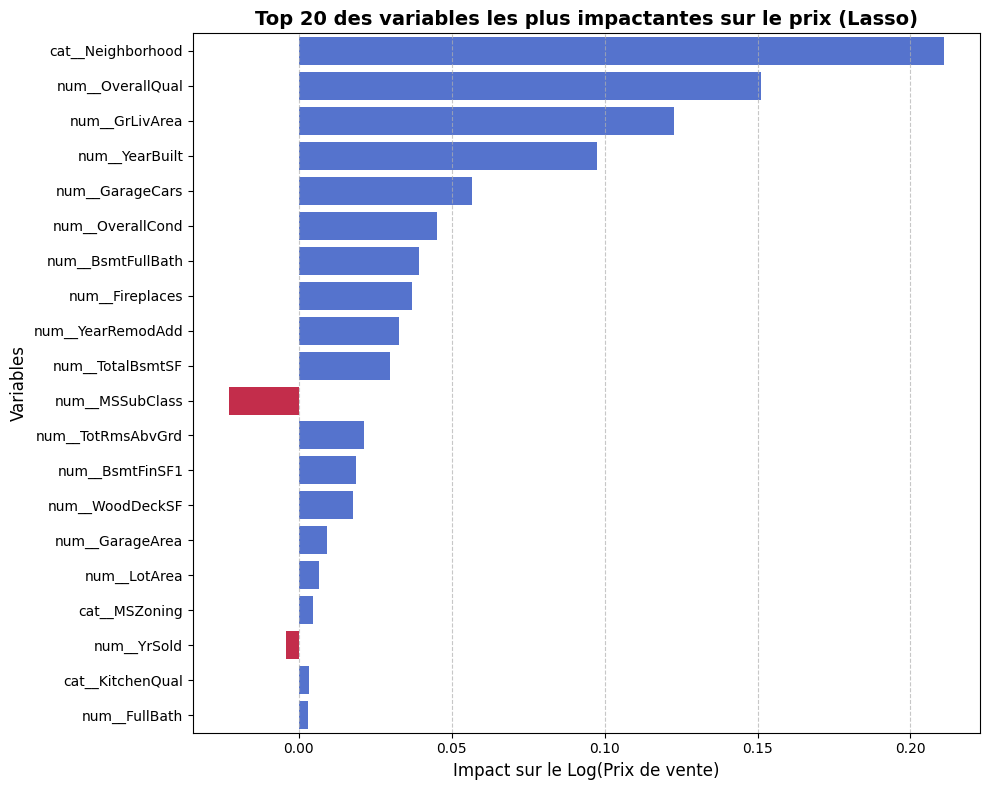

In [22]:
# 8. VISUALISATION : TOP 20 DES VARIABLES LES PLUS IMPORTANTES

# 1. Récupérer le nom de toutes les colonnes APRÈS le preprocessing
feature_names = pipeline_lasso.named_steps['preprocessor'].get_feature_names_out()

# 2. Créer un DataFrame associant le nom de la variable à son coefficient
coefs_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': lasso_model.coef_
})

# 3. On filtre pour enlever les variables que le Lasso a mises à 0
coefs_df = coefs_df[coefs_df['Coefficient'] != 0]

# 4. On crée une colonne avec la valeur absolue pour trouver les plus impactantes
coefs_df['Abs_Coefficient'] = coefs_df['Coefficient'].abs()

# 5. On prend le Top 20
top_20_features = coefs_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# 6. Création de la liste des couleurs (bleu si positif, rouge si négatif)
couleurs = top_20_features['Coefficient'].apply(lambda x: 'crimson' if x < 0 else 'royalblue').tolist()

# 7. Création du graphique
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_20_features,
    x='Coefficient',
    y='Variable',
    palette=couleurs,
    legend=False
)

plt.title("Top 20 des variables les plus impactantes sur le prix (Lasso)", fontsize=14, fontweight='bold')
plt.xlabel("Impact sur le Log(Prix de vente)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Commentaire pour le Notebook :
# Les barres bleues (positives) augmentent le prix de la maison (ex: grande surface, quartier très coté).
# Les barres rouges (négatives) diminuent le prix de la maison (ex: mauvaise qualité, proximité d'une route bruyante).

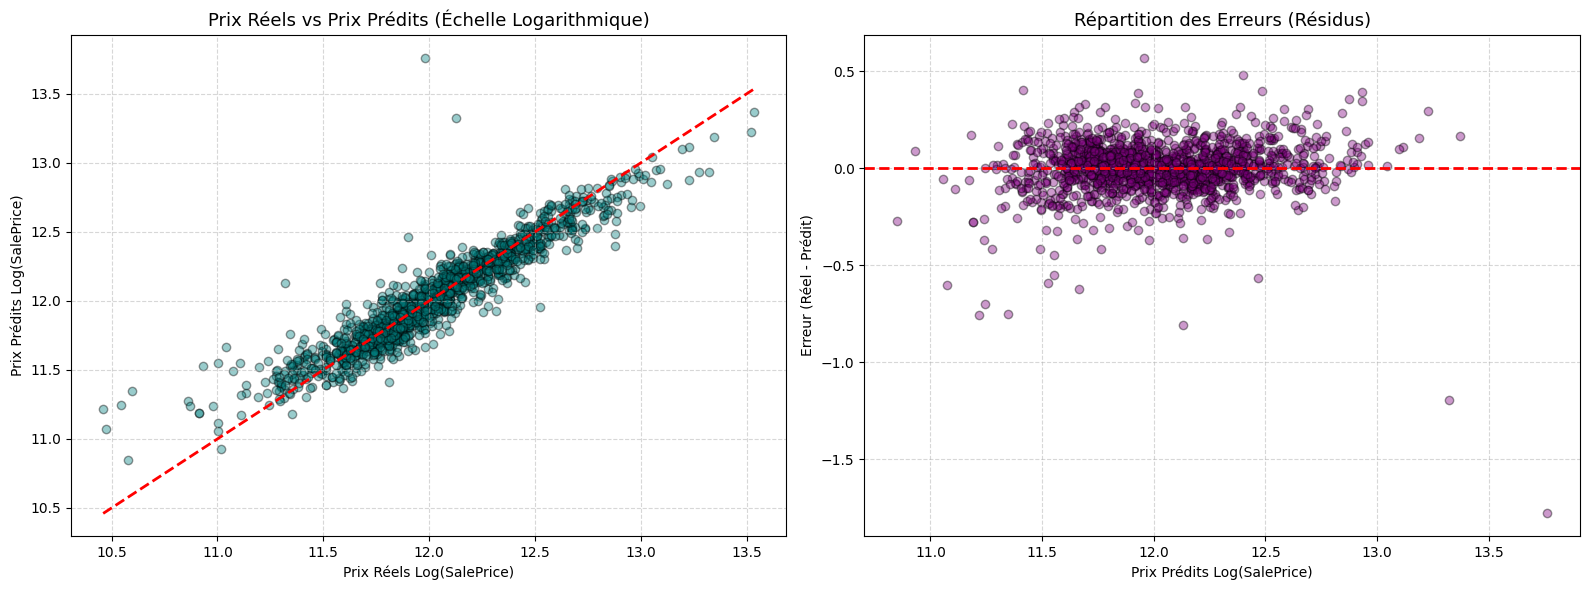

In [23]:
# 9. VISUALISATION : PERFORMANCES DU MODÈLE ET RÉSIDUS

# On prépare la figure pour avoir 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Valeurs Réelles vs Valeurs Prédites ---
axes[0].scatter(y_train, y_pred_train, alpha=0.4, color='teal', edgecolor='k')
# On trace la ligne rouge en pointillés parfaite (où Prédiction = Réalité)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)

axes[0].set_title("Prix Réels vs Prix Prédits (Échelle Logarithmique)", fontsize=13)
axes[0].set_xlabel("Prix Réels Log(SalePrice)")
axes[0].set_ylabel("Prix Prédits Log(SalePrice)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Graphique 2 : Analyse des Résidus (Erreurs) ---
# Le résidu, c'est la différence entre ce qu'on a prédit et la réalité
residus = y_train - y_pred_train

axes[1].scatter(y_pred_train, residus, alpha=0.4, color='purple', edgecolor='k')
# On trace la ligne rouge à 0 (l'endroit où l'erreur est nulle)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)

axes[1].set_title("Répartition des Erreurs (Résidus)", fontsize=13)
axes[1].set_xlabel("Prix Prédits Log(SalePrice)")
axes[1].set_ylabel("Erreur (Réel - Prédit)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Commentaire pour le Notebook :
# Graphique de gauche : Plus les points sont proches de la ligne rouge, meilleur est le modèle.
# Graphique de droite : On vérifie qu'il n'y a pas de "pattern" ou de forme en entonnoir (homoscédasticité).
# Les erreurs doivent être réparties de manière aléatoire autour de la ligne du zéro.